In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pysam
from Bio.Seq import Seq
import h5py
import random

# Getting the coordinates

In [42]:
ml_response = pd.read_csv('data/psi_response.csv')
ml_response

,event_id,gene_id,K562_summed_tpm,GM12878_summed_tpm,K562_alt_tpm,GM12878_alt_tpm,K562_gene_level_tpm,GM12878_gene_level_tpm,K562_SE_psi,GM12878_SE_psi
0,ENSG00000224051;SE:chr1:1325102-1326836:132703...,ENSG00000224051,0.499687,1.133219,0.492760,1.120903,0.576341,1.146438,0.983660,0.971831
1,ENSG00000160072;SE:chr1:1486668-1487863:148791...,ENSG00000160072,1.236285,1.539202,1.172019,1.475816,1.344589,1.576687,0.861646,0.863808
2,ENSG00000160072;SE:chr1:1489274-1489692:148981...,ENSG00000160072,1.172019,1.475816,0.611723,0.610660,1.344589,1.576687,0.270325,0.133512
3,ENSG00000197530;SE:chr1:1624901-1624991:162518...,ENSG00000197530,0.220108,0.382017,0.184691,0.359835,0.833147,1.226858,0.916667,0.948052
4,ENSG00000197530;SE:chr1:1625653-1626650:162675...,ENSG00000197530,0.089905,0.120574,0.064458,0.089905,0.833147,1.226858,0.938053,0.926230
...,...,...,...,...,...,...,...,...,...,...
24946,ENSG00000259207;AR:chr17:47284695-47286260:472...,ENSG00000259207,0.201397,1.089905,-1.000000,-1.000000,0.201397,1.089905,1.000000,1.000000
24947,ENSG00000259207;AR:chr17:47290274-47290954:472...,ENSG00000259207,0.120574,1.070407,-1.000000,-1.000000,0.201397,1.089905,1.000000,1.000000
24948,ENSG00000259207;AR:chr17:47291088-47292139:472...,ENSG00000259207,0.120574,1.070407,-1.000000,-1.000000,0.201397,1.089905,1.000000,1.000000
24949,ENSG00000259305;AR:chr8:123231757-123237798:12...,ENSG00000259305,0.733197,0.445604,-1.000000,-1.000000,0.744293,0.460898,1.000000,1.000000


In [43]:
def get_coordinates(event):
    """
    Get the coordinates of the event, in terms of intron1, exon, and intron2.
    Respects strand information.
    """
    event = event.split(':')
    intron1 = event[2]
    intron2 = event[3]
    strand = event[4]
    exon_start = intron1.split('-')[1]
    exon_end = intron2.split('-')[0]
    exon1 = f"{exon_start}-{exon_end}"
    if strand == '+':
        return (":".join(event), intron1, exon1, intron2)
    else:
        return (":".join(event), intron2, exon1, intron1)

In [44]:
coordinates = ml_response['event_id'].apply(get_coordinates)

exon_coordinates = pd.DataFrame(coordinates.to_list(), columns=['event_id', 'upstream', 'exon', 'downstream'])
exon_coordinates['upstream_length'] = exon_coordinates['upstream'].apply(lambda x: int(x.split('-')[1]) - int(x.split('-')[0]))
exon_coordinates['exon_length'] = exon_coordinates['exon'].apply(lambda x: int(x.split('-')[1]) - int(x.split('-')[0]))
exon_coordinates['downstream_length'] = exon_coordinates['downstream'].apply(lambda x: int(x.split('-')[1]) - int(x.split('-')[0]))
exon_coordinates

,event_id,upstream,exon,downstream,upstream_length,exon_length,downstream_length
0,ENSG00000224051;SE:chr1:1325102-1326836:132703...,1325102-1326836,1326836-1327032,1327032-1327241,1734,196,209
1,ENSG00000160072;SE:chr1:1486668-1487863:148791...,1486668-1487863,1487863-1487914,1487914-1489204,1195,51,1290
2,ENSG00000160072;SE:chr1:1489274-1489692:148981...,1489274-1489692,1489692-1489811,1489811-1490257,418,119,446
3,ENSG00000197530;SE:chr1:1624901-1624991:162518...,1624901-1624991,1624991-1625185,1625185-1625286,90,194,101
4,ENSG00000197530;SE:chr1:1625653-1626650:162675...,1625653-1626650,1626650-1626754,1626754-1626837,997,104,83
...,...,...,...,...,...,...,...
24946,ENSG00000259207;AR:chr17:47284695-47286260:472...,47284695-47286260,47286260-47286422,47286422-47287070,1565,162,648
24947,ENSG00000259207;AR:chr17:47290274-47290954:472...,47290274-47290954,47290954-47291088,47291088-47292139,680,134,1051
24948,ENSG00000259207;AR:chr17:47291088-47292139:472...,47291088-47292139,47292139-47292568,47292568-47299308,1051,429,6740
24949,ENSG00000259305;AR:chr8:123231757-123237798:12...,123237941-123239049,123237798-123237941,123231757-123237798,1108,143,6041


In [45]:
# remove rows where upstream_length or downstream_length is >10000
exon_coordinates_filtered = exon_coordinates[(exon_coordinates['upstream_length'] < 10000) & (exon_coordinates['downstream_length'] < 10000)]

# remove rows where exon_length is >1000
exon_coordinates_filtered = exon_coordinates_filtered[exon_coordinates_filtered['exon_length'] < 1000]

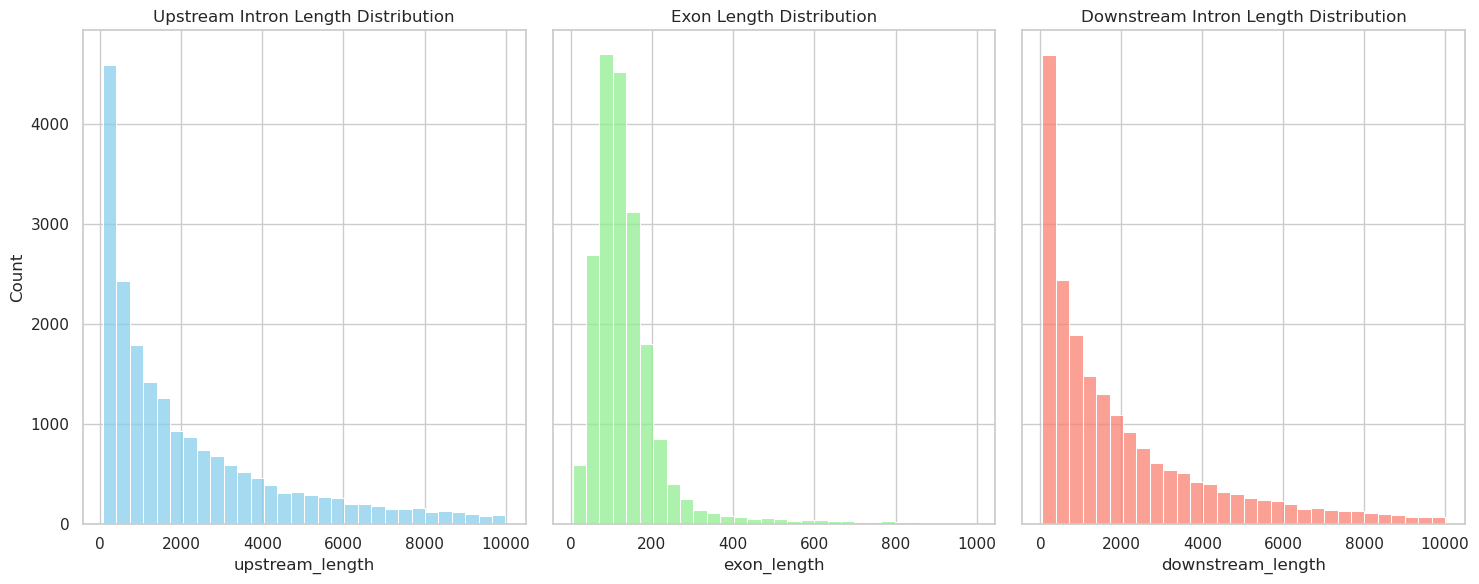

In [46]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
sns.histplot(data=exon_coordinates_filtered, x='upstream_length', bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Upstream Intron Length Distribution')
sns.histplot(data=exon_coordinates_filtered, x='exon_length', bins=30, ax=axes[1], color='lightgreen')
axes[1].set_title('Exon Length Distribution')
sns.histplot(data=exon_coordinates_filtered, x='downstream_length', bins=30, ax=axes[2], color='salmon')
axes[2].set_title('Downstream Intron Length Distribution')
plt.tight_layout()
plt.show()

# Extracting the sequences

In [47]:
# read fasta file
fasta_file = pysam.FastaFile('/nfs/data/references/GCA_000001405.15_GRCh38/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna')

In [48]:
event_sequences = {}
n_poison = 0
poisoned_events = []

for row in exon_coordinates.iterrows():
    event_id = row[1]['event_id']
    upstream = row[1]['upstream']
    exon = row[1]['exon']
    downstream = row[1]['downstream']
    chromosome = event_id.split(':')[1]
    strand = event_id.split(':')[4]

    regions = [upstream, exon, downstream]
    region_names = ['upstream', 'exon', 'downstream']
    sequences = {}
    contains_n = False
    for region, name in zip(regions, region_names):
        start = int(region.split('-')[0])
        end = int(region.split('-')[1])
        if name != 'exon':
            end -= 1
        else:
            start -= 1
        seq = fasta_file.fetch(chromosome, start, end)

        if strand == '-':
            seq = str(Seq(seq).reverse_complement())
        if "N" in seq:
            contains_n = True
        sequences[f"{region}:{name}"] = seq
    if contains_n:
        n_poison += 1
        poisoned_events.append(event_id)
        continue
    event_sequences[event_id] = sequences

print(f"Sequences for {len(event_sequences)} events have been extracted.")
print(f"Number of events with 'N' in sequence: {n_poison}")

Sequences for 24938 events have been extracted.
Number of events with 'N' in sequence: 13


In [49]:
print(list(event_sequences.keys())[33]) 
seq = fasta_file.fetch('chr1', 11981800, 11981860)
print(seq)  # Example sequence output for verification

ENSG00000116688;SE:chr1:11980484-11981970:11982114-11989165:+
TTTCCCCAGGGCACTTCCTCACATGCCAGCGCAACTCCCCAATACCTCAATGAGTAAGCT


In [50]:
for i in [33, 844, 6872, 6101, 6249, 5581, 3660, 5302, 352, 7379]:
    print(f"{i}: {list(event_sequences.keys())[i]}")
    print(event_sequences[list(event_sequences.keys())[i]])


33: ENSG00000116688;SE:chr1:11980484-11981970:11982114-11989165:+
{'11980484-11981970:upstream': 'GTGAGAGGGCGAGCAAGCCGGGGTGGCGGGGACTGGCCCGGCCCGGCCCGGCGAGTCCTGAGCAGCTCGGCGTGGGCCGACGGGATTCTGGGGCCACGGGGGTCTGGGATGCAGTCAAGCGGGGTCCCCACTCTCCGGCCTCGCCGCCGGGCCCTCCCCGGCCCTGAGAGGAGGGGGCGGGCCACGGGACCTGGGACTGGTCGGTGGGGTCCCCTGTAGCTTCTCATCGCCCCCGCCTTTCCACCCTTCACGGCCATGTTCTACCCCTGCCCCTTCTCTATTTTTCATCCTGTCTTCATTTTGCCAGCATTTACTCAGCACCTGATAGGTGTCCACGTTCACCGCGGGAGCGCCCTGCCATCCCCACTTTGGGCAGTTACTGCCTTCTCGTTCAGCCCTGTTTACTTATATGACTTCTCACCGGACTGTAAGGCCCTGGAGGGCAGGACTGTTTCTTATCCATTTCTAACGTGGCGCCTGACACACACAGAGAAGGCACACAGAAAATGTTGAATAAATAGCTGTTAAGACGCACGAAGGCAGAACTGCCCGTTACCCCCTCTCGTAATCCTTCATTGCCCTCTTTAAATTCTCAATCATCTCTCTCTCTTCTACCCAGAAAAGGGCTCTGGTTATCTCTTTTCTACCCAGAAAAGGGCTCTGGTTATCCGCCTCTGGTGTCCCAAGGTTTGGGGCTTGGGGGAGGAAGGCAGCTCAATGTAGTTAAAAAAGGAAGGAGGCCGGTCGCAGTGGATCACACCTGTAATCCCAGCACTTTGGGAGGCTGAGGCGGGCGGATCACCTGAGGTCAGGAGTTGGAGACCAGCCTGGCCAACATGGTGAAACCCCGTCTGTGCTAAAACCAAAAACTAGCCGGGCTTGCTGGCACACGCCTGTAATCC

In [51]:
# save the sequences to a h5 file
with h5py.File('data/event_sequences.h5', 'w') as f:
    for event_id, sequences in event_sequences.items():
        group = f.create_group(event_id)
        for region, seq in sequences.items():
            group.create_dataset(region, data=np.bytes_(seq))

In [52]:
# remove poisoned events from the ml_response dataframe
ml_response_filtered = ml_response[~ml_response['event_id'].isin(poisoned_events)]
# save the filtered ml_response dataframe
ml_response_filtered.to_csv('data/psi_response_filtered.csv', index=False)

In [53]:
# read h5 file
event_keys = []
with h5py.File('data/event_sequences.h5', 'r') as f:
    print(f"Size: {len(f.keys())}")
    event_keys = list(f.keys())
    for event_id in f.keys():
        print(f"Event ID: {event_id}")
        for region in f[event_id].keys():
            print(f"  {region}: {f[event_id][region][()]}")
        break  # Just read the first event

gene_ids = []
with h5py.File('data/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r') as f:
    print(f"Keys: {list(f.keys())}")
    for ens_id in f['ensid']:
        gene_ids.append(ens_id.decode())
    print(f"Gene IDs: {gene_ids[:5]}")  # Display first 5 gene IDs

gene_ids = set(gene_ids)

found = 0
total = 0
for event in event_keys:
    gene_id = event.split(';')[0]
    if gene_id in gene_ids:
        found += 1
    total += 1
print(f"Found {found}/{total} events in the gene IDs.")

Size: 24938
Event ID: ENSG00000000003;AR:chrX:100633539-100633931:100634029-100635178:-
  100633539-100633931:downstream: b'GTAAGTGGTAACCACCACCTAGAGGGGAACACATTCCCTGTTGCCTCAGAGAAAAGAGCAGAGTCTGGCTACTAGATGTTATCCACCTGTAGGGGAAAGAAGTGTGACGTGTTTCATTTTCCTCACATGTGCACCTGTTCTCTTCCTTCCCCACTTACATCATAGTCCAGGTACAGTTAGTACCAACTATAGCAGGAAAGTAAGGCCAATACAAAACTGTCATGCATGGTGCTAATCAGGGACCCAGTGCTCATCTCTTGAATCAATTGAGGAGAGAGATCATTGAGATTAGTAAATGTTTTGAGCACAAATTGCAATAGAGGATATTAGGTTAAATGTTTGACTACAAAGTTGTAATATAAACTGTAAATGCTTTTGTTGGGTTTTTCAG'
  100633931-100634029:exon: b'ATTAAGAACAGCTTTAAGAATAATTATGAGAAGGCTTTGAAGCAGTATAACTCTACAGGAGATTATAGAAGCCATGCAGTAGACAAGATCCAAAATACG'
  100634029-100635178:upstream: b'GTAAGCCTGAATTAGGGAAGCTTAGCATGTTACATTTATCCTCTGAGAGATAAAAATGGATTTATTAAAGTAGAAGAGTCAGACCTCTGTATTTAAACCTGTAGCTGACAATAATGGCCTTCTTGTAAAAATTCTGGTCCACTTCTAATTTAAAAGAAAATTTAGAAAATTGTAAAGACTGATAGTCACCAGAAGAAAATTACTTACTTATATTCCCTGTCGTTTTTCTGTGTATAAATACCTATTAAAACGGAGATAGTACAATTTATAACTTTGCTGATAGGAAAATATTCAAAGCACAAAATTGATAACCTTCTT